## Python codes for the numerical simulations, sensitivity analysis and bifurcation analysis.

In [1]:
#import libraries
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.pyplot as plt

## Sensitivity Analysis 

   Parameter     Index
       $\mu$ -1.076936
       $\nu$ -0.780031
    $\sigma$ -0.471651
  $\tau_{2}$ -0.293760
$\gamma_{1}$ -0.227506
$\delta_{1}$ -0.168811
  $\tau_{1}$ -0.126277
$\delta_{2}$ -0.121696
     $F_{S}$ -0.112498
$\gamma_{2}$ -0.051302
$\delta_{3}$ -0.051302
$\alpha_{3}$  0.000230
    $\kappa$  0.008133
$\beta_{h1}$  0.039968
$\alpha_{2}$  0.050778
$\alpha_{1}$  0.061489
  $\rho_{2}$  0.103445
 $\beta_{f}$  0.112498
         $z$  0.198471
  $\rho_{1}$  0.232170
$\beta_{h2}$  0.369667
 $\beta_{c}$  0.477867
   $\Lambda$  1.000000


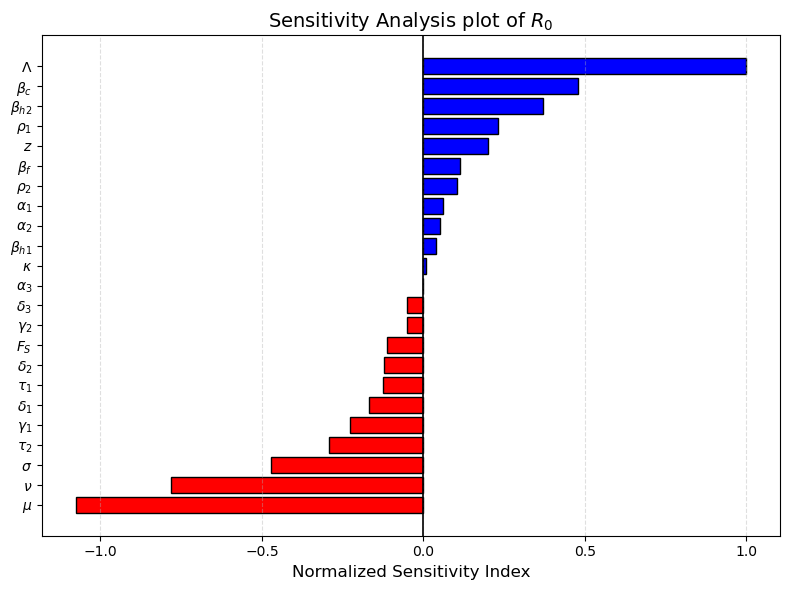

In [2]:
# Sensitivity Analysis

# define baseline parameters
p = {
    'beta_h1': 0.02, 'beta_h2': 0.28, 'beta_c': 0.4, 'beta_f': 0.01,
    'z': 0.30, 'rho1': 0.10, 'rho2': 0.14, 'tau1': 0.40, 'tau2': 0.35,
    'gamma1': 0.20, 'gamma2': 0.25, 'delta1': 0.143, 'delta2': 0.10,
    'delta3': 0.25, 'alpha1': 0.40, 'alpha2': 0.50, 'alpha3': 0.0025,
    'FS': 0.13, 'sigma': 0.30, 'mu': 0.0041, 'Lambda': 0.75,
    'kappa': 0.50, 'nu': 0.05, 'omega': 0.0814, 'epsilon': 0.01
}

# derived grouped parameters
a1 = p['kappa'] + p['mu']
a2 = p['z'] + p['tau1'] + p['mu'] + p['delta1']
a3 = p['tau2'] + p['mu'] + p['delta2']
a4 = p['rho1'] + p['gamma1'] + p['mu']
a5 = p['rho2'] + p['gamma2'] + p['mu'] + p['delta3']
a6 = p['sigma'] + p['mu']

# defined paths
H1, H2 = p['beta_h1'], (p['z']*p['beta_h2'])/a3
H3, H4 = (p['beta_c']*p['rho1']*p['tau1'])/(a4*a6), (p['beta_c']*p['z']*p['rho2']*p['tau2'])/(a3*a5*a6)
H_tot = H1 + H2 + H3 + H4

E1, E2 = p['alpha1'], (p['z']*p['alpha2'])/a3
E3, E4 = (p['alpha3']*p['rho1']*p['tau1'])/(a4*a6), (p['alpha3']*p['z']*p['rho2']*p['tau2'])/(a3*a5*a6)
E_tot = (p['beta_f']/p['FS']) * (E1 + E2 + E3 + E4)

A = H_tot + E_tot

#analytical sensitivity computation
s = {}

# Primary scaling
s[r'$\Lambda$'] = 1.0
s[r'$\beta_{f}$'] = E_tot / A
s[r'$F_{S}$'] = - E_tot / A
s[r'$\beta_{h1}$'] = H1 / A
s[r'$\beta_{h2}$'] = H2 / A
s[r'$\alpha_{1}$'] = ((p['beta_f']/p['FS']) * E1) / A
s[r'$\alpha_{2}$'] = ((p['beta_f']/p['FS']) * E2) / A

# Interventions
s[r'$\nu$'] = - p['nu'] / (p['mu'] + p['nu'] + p['epsilon'])
s[r'$\tau_{1}$'] = (p['tau1']/A) * ((p['beta_c']*p['rho1']/(a4*a6)) + (p['beta_f']/p['FS']*p['alpha3']*p['rho1']/(a4*a6))) - (p['tau1']/a2)
s[r'$\tau_{2}$'] = (p['tau2']/A) * (-(H2 + (p['beta_f']/p['FS'])*E2)/a3 + (H4 + (p['beta_f']/p['FS'])*E4)/p['tau2'] * (1 - p['tau2']/a3))
s[r'$\sigma$'] = -(p['sigma']/a6) * (H3 + H4 + (p['beta_f']/p['FS'])*(E3 + E4)) / A

# Recovery & Mortality
s[r'$\gamma_{1}$'] = -(p['gamma1']/a4) * (H3 + (p['beta_f']/p['FS'])*E3) / A
s[r'$\gamma_{2}$'] = -(p['gamma2']/a5) * (H4 + (p['beta_f']/p['FS'])*E4) / A
s[r'$\delta_{1}$'] = -p['delta1'] / a2
s[r'$\delta_{2}$'] = -(p['delta2']/a3) * (H2 + H4 + (p['beta_f']/p['FS'])*(E2 + E4)) / A
s[r'$\delta_{3}$'] = -(p['delta3']/a5) * (H4 + (p['beta_f']/p['FS'])*E4) / A

# Transitions
s[r'$z$'] = (p['z']/A) * (p['beta_h2']/a3 + (p['beta_c']*p['rho2']*p['tau2'])/(a3*a5*a6) + (p['beta_f']/p['FS'])*(p['alpha2']/a3 + (p['alpha3']*p['rho2']*p['tau2'])/(a3*a5*a6))) - (p['z']/a2)
s[r'$\rho_{1}$'] = (p['rho1']/A) * (H3/p['rho1']*(1 - p['rho1']/a4) + (p['beta_f']/p['FS'])*E3/p['rho1']*(1 - p['rho1']/a4))
s[r'$\rho_{2}$'] = (p['rho2']/A) * (H4/p['rho2']*(1 - p['rho2']/a5) + (p['beta_f']/p['FS'])*E4/p['rho2']*(1 - p['rho2']/a5))

# System constants
s[r'$\kappa$'] = 1 - (p['kappa']/a1)
#s[r'$\epsilon$'] = (p['epsilon']/(p['mu'] + p['epsilon'])) - (p['epsilon']/(p['mu'] + p['nu'] + p['epsilon']))
s[r'$\mu$'] = -1 - (p['mu']/(p['mu'] + p['nu'] + p['epsilon'])) - (p['mu']/a1) - (p['mu']/a2)
s[r'$\beta_{c}$'] = (H3 + H4) / A
s[r'$\alpha_{3}$'] = ((p['beta_f']/p['FS']) * (E3 + E4)) / A
#s[r'$\omega$'] = 0.0


# 4. VISUALIZATION

df = pd.DataFrame({'Parameter': list(s.keys()), 'Index': list(s.values())}).sort_values(by='Index')
print(df.to_string(index=False))

plt.figure(figsize=(8, 6))
plt.barh(df['Parameter'], df['Index'], color=['red' if x < 0 else 'blue' for x in df['Index']], edgecolor='black')
plt.axvline(x=0, color='black', lw=1.2)
plt.xlabel('Normalized Sensitivity Index', fontsize=12)
plt.title(r'Sensitivity Analysis plot of $R_0$', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
#plt.savefig("Sensitvity-Index.pdf", dpi=100, bbox_inches='tight')

plt.show()



## Numerical Simulation

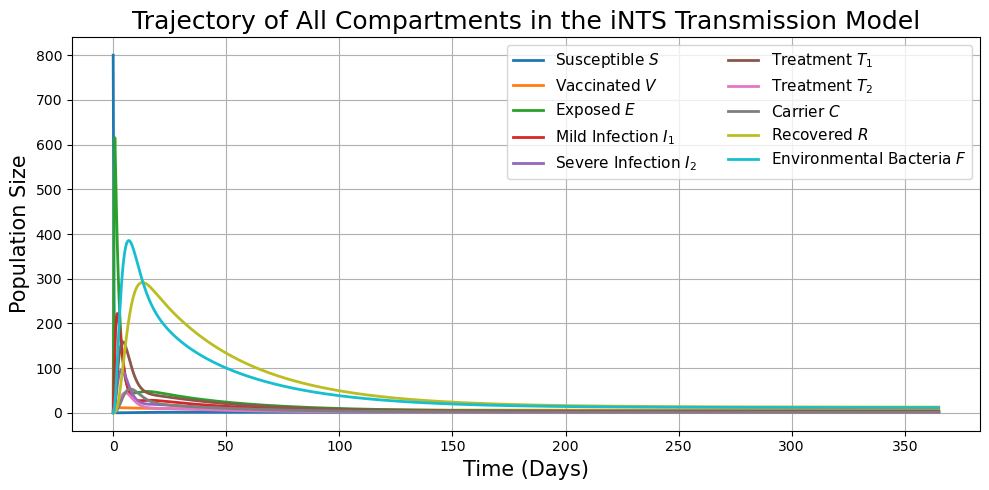

In [23]:

#Trajectory plot for all model compartments

# parameter values
Lambda = 0.75 

beta_h1 = 0.02
beta_h2 = 0.28
beta_c  = 0.40
beta_f  = 0.01

z = 0.30

rho1 = 0.1
rho2 = 0.14

tau1 = 0.40
tau2 = 0.35

gamma1 = 0.20
gamma2 = 0.25

delta1 = 0.143
delta2 = 0.10
delta3 = 0.25

alpha1 = 0.40
alpha2 = 0.50
alpha3 = 0.0025

FS = 0.13

sigma = 0.30

mu = 0.0041

kappa = 0.50

nu = 0.05

epsilon = 0.01

omega = 0.0814

# define model system

def iNTS_model(t, y):

    S, V, E, I1, I2, T1, T2, C, R, F = y

    
    #force of infection
    
    lam = (
        beta_h1 * I1
        + beta_h2 * I2
        + beta_c * C
        + beta_f * F
    )

    # differential equations

    dSdt = (
        Lambda
        + omega * R
        + epsilon * V
        - lam * S
        - (nu + mu) * S
    )

    dVdt = (
        nu * S
        - (epsilon + mu) * V
    )

    dEdt = (
        lam * S
        - (kappa + mu) * E
    )

    dI1dt = (
        kappa * E
        - (z + tau1 + mu + delta1) * I1
    )

    dI2dt = (
        z * I1
        - (tau2 + mu + delta2) * I2
    )

    dT1dt = (
        tau1 * I1
        - (rho1 + gamma1 + mu) * T1
    )

    dT2dt = (
        tau2 * I2
        - (rho2 + gamma2 + mu + delta3) * T2
    )

    dCdt = (
        rho1 * T1
        + rho2 * T2
        - (sigma + mu) * C
    )

    dRdt = (
        gamma1 * T1
        + gamma2 * T2
        + sigma * C
        - (omega + mu) * R
    )

    dFdt = (
        alpha1 * I1
        + alpha2 * I2
        + alpha3 * C
        - FS * F
    )

    return [
        dSdt,
        dVdt,
        dEdt,
        dI1dt,
        dI2dt,
        dT1dt,
        dT2dt,
        dCdt,
        dRdt,
        dFdt
    ]


#set initial conditions

S0  = 800
V0  = 0
E0  = 20
I10 = 10
I20 = 5
T10 = 0
T20 = 0
C0  = 2
R0  = 0
F0  = 0.1

initial_conditions = [
    S0,
    V0,
    E0,
    I10,
    I20,
    T10,
    T20,
    C0,
    R0,
    F0
]


# time interval
t_start = 0
t_end = 365

t_eval = np.linspace(t_start, t_end, 1000)


# solve the system of ODEs

solution = solve_ivp(
    iNTS_model,
    [t_start, t_end],
    initial_conditions,
    t_eval=t_eval,
    method='RK45'
)


#extract solutions

t  = solution.t

S  = solution.y[0]
V  = solution.y[1]
E  = solution.y[2]
I1 = solution.y[3]
I2 = solution.y[4]
T1 = solution.y[5]
T2 = solution.y[6]
C  = solution.y[7]
R  = solution.y[8]
F  = solution.y[9]


# plot trajectories

plt.figure(figsize=(10,5))

plt.plot(t, S,  linewidth=2, label='Susceptible $S$')
plt.plot(t, V,  linewidth=2, label='Vaccinated $V$')
plt.plot(t, E,  linewidth=2, label='Exposed $E$')
plt.plot(t, I1, linewidth=2, label='Mild Infection $I_1$')
plt.plot(t, I2, linewidth=2, label='Severe Infection $I_2$')
plt.plot(t, T1, linewidth=2, label='Treatment $T_1$')
plt.plot(t, T2, linewidth=2, label='Treatment $T_2$')
plt.plot(t, C,  linewidth=2, label='Carrier $C$')
plt.plot(t, R,  linewidth=2, label='Recovered $R$')
plt.plot(t, F,  linewidth=2, label='Environmental Bacteria $F$')


#figure settings

plt.xlabel('Time (Days)', fontsize=15)

plt.ylabel('Population Size', fontsize=15)

plt.title(
    'Trajectory of All Compartments in the iNTS Transmission Model',
    fontsize=18
)

plt.legend(
    fontsize=11,
    loc='upper right',
    ncol=2
)

plt.grid(True)

plt.tight_layout()
#plt.savefig("Traj_comp.png", dpi=100, bbox_inches='tight')

plt.show()

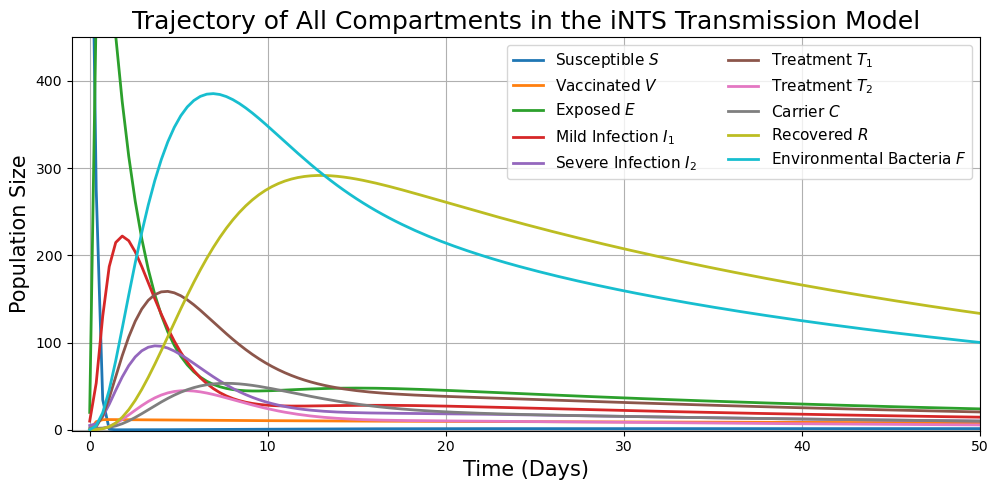

In [6]:

#Trajectory plot for all model compartments

# parameter values
Lambda = 0.75 

beta_h1 = 0.02
beta_h2 = 0.28
beta_c  = 0.40
beta_f  = 0.01

z = 0.30

rho1 = 0.1
rho2 = 0.14

tau1 = 0.40
tau2 = 0.35

gamma1 = 0.20
gamma2 = 0.25

delta1 = 0.143
delta2 = 0.10
delta3 = 0.25

alpha1 = 0.40
alpha2 = 0.50
alpha3 = 0.0025

FS = 0.13

sigma = 0.30

mu = 0.0041

kappa = 0.50

nu = 0.05

epsilon = 0.01

omega = 0.0814

#define model system

def iNTS_model(t, y):

    S, V, E, I1, I2, T1, T2, C, R, F = y

    
    #force of infection
    
    lam = (
        beta_h1 * I1
        + beta_h2 * I2
        + beta_c * C
        + beta_f * F
    )

    # differential equations

    dSdt = (
        Lambda
        + omega * R
        + epsilon * V
        - lam * S
        - (nu + mu) * S
    )

    dVdt = (
        nu * S
        - (epsilon + mu) * V
    )

    dEdt = (
        lam * S
        - (kappa + mu) * E
    )

    dI1dt = (
        kappa * E
        - (z + tau1 + mu + delta1) * I1
    )

    dI2dt = (
        z * I1
        - (tau2 + mu + delta2) * I2
    )

    dT1dt = (
        tau1 * I1
        - (rho1 + gamma1 + mu) * T1
    )

    dT2dt = (
        tau2 * I2
        - (rho2 + gamma2 + mu + delta3) * T2
    )

    dCdt = (
        rho1 * T1
        + rho2 * T2
        - (sigma + mu) * C
    )

    dRdt = (
        gamma1 * T1
        + gamma2 * T2
        + sigma * C
        - (omega + mu) * R
    )

    dFdt = (
        alpha1 * I1
        + alpha2 * I2
        + alpha3 * C
        - FS * F
    )

    return [
        dSdt,
        dVdt,
        dEdt,
        dI1dt,
        dI2dt,
        dT1dt,
        dT2dt,
        dCdt,
        dRdt,
        dFdt
    ]


#set initial conditions

S0  = 800
V0  = 0
E0  = 20
I10 = 10
I20 = 5
T10 = 0
T20 = 0
C0  = 2
R0  = 0
F0  = 0.1

initial_conditions = [
    S0,
    V0,
    E0,
    I10,
    I20,
    T10,
    T20,
    C0,
    R0,
    F0
]


# time interval
t_start = 0
t_end = 365

t_eval = np.linspace(t_start, t_end, 1000)


# solve the system of ODEs

solution = solve_ivp(
    iNTS_model,
    [t_start, t_end],
    initial_conditions,
    t_eval=t_eval,
    method='RK45'
)


#extract solutions

t  = solution.t

S  = solution.y[0]
V  = solution.y[1]
E  = solution.y[2]
I1 = solution.y[3]
I2 = solution.y[4]
T1 = solution.y[5]
T2 = solution.y[6]
C  = solution.y[7]
R  = solution.y[8]
F  = solution.y[9]


# plot trajectories

plt.figure(figsize=(10,5))

plt.plot(t, S,  linewidth=2, label='Susceptible $S$')
plt.plot(t, V,  linewidth=2, label='Vaccinated $V$')
plt.plot(t, E,  linewidth=2, label='Exposed $E$')
plt.plot(t, I1, linewidth=2, label='Mild Infection $I_1$')
plt.plot(t, I2, linewidth=2, label='Severe Infection $I_2$')
plt.plot(t, T1, linewidth=2, label='Treatment $T_1$')
plt.plot(t, T2, linewidth=2, label='Treatment $T_2$')
plt.plot(t, C,  linewidth=2, label='Carrier $C$')
plt.plot(t, R,  linewidth=2, label='Recovered $R$')
plt.plot(t, F,  linewidth=2, label='Environmental Bacteria $F$')


#figure settings

plt.xlabel('Time (Days)', fontsize=15)

plt.ylabel('Population Size', fontsize=15)

plt.title(
    'Trajectory of All Compartments in the iNTS Transmission Model',
    fontsize=18
)

plt.legend(
    fontsize=11,
    loc='upper right',
    ncol=2
)

plt.grid(True)

plt.tight_layout()
#plt.ylim(-1, 450)
#plt.xlim(-1, 50)
plt.savefig("Traj_comp_3.png", dpi=100, bbox_inches='tight')
plt.show()

## Impact of vaccination

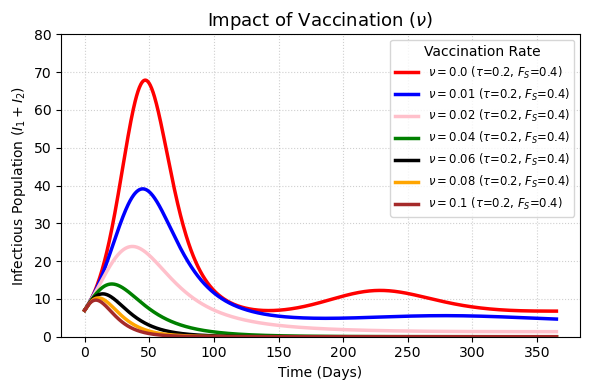

In [5]:

#  The Full 10-Compartment iNTS Model Equations
def ints_ode(y, t, p):
    # S, V, E, I1, I2, T1, T2, C, R, F_env
    S, V, E, I1, I2, T1, T2, C, R, F_env = y
    N = S + V + E + I1 + I2 + T1 + T2 + C + R
    
    # Force of Infection (lambda)
    lam = (p['bh1']*I1 + p['bh2']*I2 + p['bc']*C + p['bf']*F_env) / N
    
    # Differential Equations from the model
    dSdt = p['Lambda'] + p['omega']*R + p['eps']*V - lam*S - (p['nu'] + p['mu'])*S
    dVdt = p['nu']*S - (p['eps'] + p['mu'])*V
    dEdt = lam*S - (p['kappa'] + p['mu'])*E
    dI1dt = p['kappa']*E - (p['z'] + p['tau1'] + p['mu'] + p['delta1'])*I1
    dI2dt = p['z']*I1 - (p['tau2'] + p['mu'] + p['delta2'])*I2
    dT1dt = p['tau1']*I1 - (p['rho1'] + p['gamma1'] + p['mu'])*T1
    dT2dt = p['tau2']*I2 - (p['rho2'] + p['gamma2'] + p['mu'] + p['delta3'])*T2
    dCdt = p['rho1']*T1 + p['rho2']*T2 - (p['sigma'] + p['mu'])*C
    dRdt = p['gamma1']*T1 + p['gamma2']*T2 + p['sigma']*C - (p['omega'] + p['mu'])*R
    dFdt = p['alpha1']*I1 + p['alpha2']*I2 + p['alpha3']*C - p['FS']*F_env
    
    return [dSdt, dVdt, dEdt, dI1dt, dI2dt, dT1dt, dT2dt, dCdt, dRdt, dFdt]

# Parameters
p_base = {
    'Lambda': 0.75, 'mu': 0.005, 'omega': 0.01, 'eps': 0.02, 'kappa': 0.2,
    'bh1': 0.3, 'bh2': 0.3, 'bc': 0.1, 'bf': 0.2, 
    'z': 0.15, 'delta1': 0.01, 'delta2': 0.02, 'delta3': 0.01,
    'rho1': 0.2, 'rho2': 0.2, 'gamma1': 0.15, 'gamma2': 0.15,
    'sigma': 0.2, 'alpha1': 0.2, 'alpha2': 0.2, 'alpha3': 0.05,
    'tau1': 0.2, 'tau2': 0.2, # FIXED Treatment 
    'FS': 0.4                 # FIXED Sanitation Decay 
}

t = np.linspace(0, 365, 1000)

# Initial Conditions
# S, V, E, I1, I2, T1, T2, C, R, F_env
y0 = [950, 20, 10, 5, 2, 0, 0, 0, 0, 5] 

# Plotting
plt.figure(figsize=(6, 4))

# Comparing different vaccination values
nu_values = [0.0, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1]
colors = ['red', 'blue', 'pink', 'green', 'black', 'orange', 'brown']

for nu, col in zip(nu_values, colors):
    p_sim = p_base.copy()
    p_sim['nu'] = nu
    sol = odeint(ints_ode, y0, t, args=(p_sim,))
    
    # Plotting Total Infectious Population (I1 + I2)
    plt.plot(t, sol[:, 3] + sol[:, 4], color=col, lw=2.5, 
             label=fr'$\nu = {nu}$ ($\tau$=0.2, $F_S$=0.4)')

plt.title('Impact of Vaccination ($\\nu$)', fontsize=13)
plt.xlabel('Time (Days)')
plt.ylabel('Infectious Population ($I_1 + I_2$)')
plt.ylim(0, 80)
plt.legend(title='Vaccination Rate', loc='upper right', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig("Impact-Vacc.png", dpi=100, bbox_inches='tight')


plt.show()

## Impact of treatment

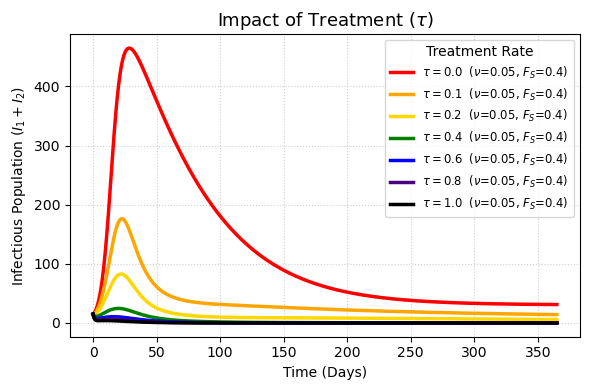

In [6]:

#  The Full 10-Compartment iNTS Model Equations
def ints_ode(y, t, p):
    # S, V, E, I1, I2, T1, T2, C, R, F_env
    S, V, E, I1, I2, T1, T2, C, R, F_env = y
    N = S + V + E + I1 + I2 + T1 + T2 + C + R
    
    # Force of Infection (lambda)
    lam = (p['bh1']*I1 + p['bh2']*I2 + p['bc']*C + p['bf']*F_env) / N
    
    dSdt = p['Lambda'] + p['omega']*R + p['eps']*V - lam*S - (p['nu'] + p['mu'])*S
    dVdt = p['nu']*S - (p['eps'] + p['mu'])*V
    dEdt = lam*S - (p['kappa'] + p['mu'])*E
    dI1dt = p['kappa']*E - (p['z'] + p['tau1'] + p['mu'] + p['delta1'])*I1
    dI2dt = p['z']*I1 - (p['tau2'] + p['mu'] + p['delta2'])*I2
    dT1dt = p['tau1']*I1 - (p['rho1'] + p['gamma1'] + p['mu'])*T1
    dT2dt = p['tau2']*I2 - (p['rho2'] + p['gamma2'] + p['mu'] + p['delta3'])*T2
    dCdt = p['rho1']*T1 + p['rho2']*T2 - (p['sigma'] + p['mu'])*C
    dRdt = p['gamma1']*T1 + p['gamma2']*T2 + p['sigma']*C - (p['omega'] + p['mu'])*R
    dFdt = p['alpha1']*I1 + p['alpha2']*I2 + p['alpha3']*C - p['FS']*F_env
    
    return [dSdt, dVdt, dEdt, dI1dt, dI2dt, dT1dt, dT2dt, dCdt, dRdt, dFdt]

# Parameters 
p_base = {
    'Lambda': 0.75, 'mu': 0.005, 'omega': 0.01, 'eps': 0.02, 'kappa': 0.2,
    'bh1': 0.4, 'bh2': 0.5, 'bc': 0.2, 'bf': 0.6, 
    'z': 0.15, 'delta1': 0.01, 'delta2': 0.02, 'delta3': 0.01,
    'rho1': 0.2, 'rho2': 0.2, 'gamma1': 0.15, 'gamma2': 0.15,
    'sigma': 0.2, 'alpha1': 0.4, 'alpha2': 0.4, 'alpha3': 0.1,
    'nu': 0.05,   # Fixed Vaccination 
    'FS': 0.4     # Fixed Sanitation Decay 
}

t = np.linspace(0, 365, 1000)

# Initial Conditions
# S, V, E, I1, I2, T1, T2, C, R, F_env
y0 = [950, 25, 10, 10, 5, 0, 0, 0, 0, 5] 

# Plotting
plt.figure(figsize=(6, 4))

# Comparing different treatment values
tau_values = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
colors = ['red', 'orange', 'gold', 'green', 'blue', 'indigo', 'black']

for tau, col in zip(tau_values, colors):
    p_sim = p_base.copy()
    p_sim['tau1'] = p_sim['tau2'] = tau
    sol = odeint(ints_ode, y0, t, args=(p_sim,))
    
    # Plot the total infectious (I1 + I2)
    plt.plot(t, sol[:, 3] + sol[:, 4], color=col, lw=2.5, 
             label=fr'$\tau = {tau}$  ($\nu$=0.05, $F_S$=0.4) ')

plt.title(r'Impact of Treatment ($\tau$)', fontsize=13)
plt.xlabel('Time (Days)')
plt.ylabel('Infectious Population ($I_1 + I_2$)')
plt.legend(title='Treatment Rate', loc='upper right', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig("Impact-treat.png", dpi=100, bbox_inches='tight')


plt.show()

## Impact of Sanitation

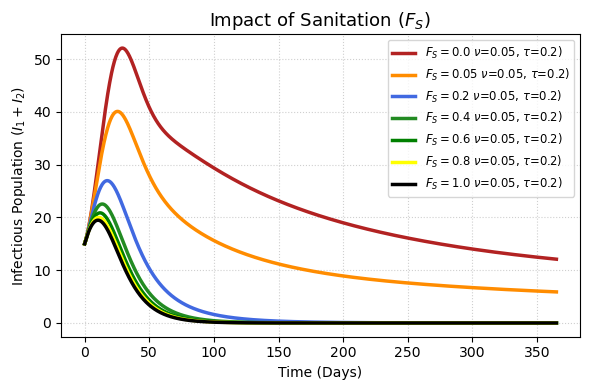

In [13]:

# The iNTS Model Equations
def ints_ode(y, t, p):
    # S, V, E, I1, I2, T1, T2, C, R, F_env
    S, V, E, I1, I2, T1, T2, C, R, F_env = y
    N = S + V + E + I1 + I2 + T1 + T2 + C + R
    
    # Force of Infection (lambda)
    lam = (p['bh1']*I1 + p['bh2']*I2 + p['bc']*C + p['bf']*F_env) / N
    
    dSdt = p['Lambda'] + p['omega']*R + p['eps']*V - lam*S - (p['nu'] + p['mu'])*S
    dVdt = p['nu']*S - (p['eps'] + p['mu'])*V
    dEdt = lam*S - (p['kappa'] + p['mu'])*E
    dI1dt = p['kappa']*E - (p['z'] + p['tau1'] + p['mu'] + p['delta1'])*I1
    dI2dt = p['z']*I1 - (p['tau2'] + p['mu'] + p['delta2'])*I2
    dT1dt = p['tau1']*I1 - (p['rho1'] + p['gamma1'] + p['mu'])*T1
    dT2dt = p['tau2']*I2 - (p['rho2'] + p['gamma2'] + p['mu'] + p['delta3'])*T2
    dCdt = p['rho1']*T1 + p['rho2']*T2 - (p['sigma'] + p['mu'])*C
    dRdt = p['gamma1']*T1 + p['gamma2']*T2 + p['sigma']*C - (p['omega'] + p['mu'])*R
    dFdt = p['alpha1']*I1 + p['alpha2']*I2 + p['alpha3']*C - p['FS']*F_env
    
    return [dSdt, dVdt, dEdt, dI1dt, dI2dt, dT1dt, dT2dt, dCdt, dRdt, dFdt]

# Parameters 
p_base = {
    'Lambda': 0.75, 'omega': 0.01, 'eps': 0.02, 'mu': 0.005,
    'bh1': 0.3, 'bh2': 0.3, 'bc': 0.1, 'bf': 0.2, 
    'kappa': 0.2, 'z': 0.15, 'delta1': 0.01, 'delta2': 0.02, 'delta3': 0.01,
    'rho1': 0.2, 'rho2': 0.2, 'gamma1': 0.15, 'gamma2': 0.15, 'sigma': 0.3,
    'alpha1': 0.2, 'alpha2': 0.2, 'alpha3': 0.05,
    'nu': 0.05,            # FIXED: Vaccination 
    'tau1': 0.2, 'tau2': 0.2 # FIXED: Treatment 
}

t = np.linspace(0, 365, 1000)
y0 = [900, 50, 20, 10, 5, 0, 0, 0, 0, 10]

# Plotting
plt.figure(figsize=(6, 4))

# Comparing different sanitation (Decay) values
fs_values = [0.0, 0.05, 0.2, 0.4,0.6, 0.8, 1.0]
colors = ['firebrick', 'darkorange', 'royalblue', 'forestgreen','green','yellow','black']

for fs, col in zip(fs_values, colors):
    p_sim = p_base.copy()
    p_sim['FS'] = fs
    sol = odeint(ints_ode, y0, t, args=(p_sim,))
    
    # Infection Trajectory (I1 + I2)
    plt.plot(t, sol[:, 3] + sol[:, 4], color=col, lw=2.5, 
             label=f'$F_S = {fs}$ $\\nu$=0.05, $\\tau$=0.2)')

plt.title('Impact of Sanitation ($F_S$) ', fontsize=13)
plt.xlabel('Time (Days)')
plt.ylabel('Infectious Population ($I_1 + I_2$)')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig("Impact-sani.png", dpi=100, bbox_inches='tight')

plt.show()

## Bifurcation analysis

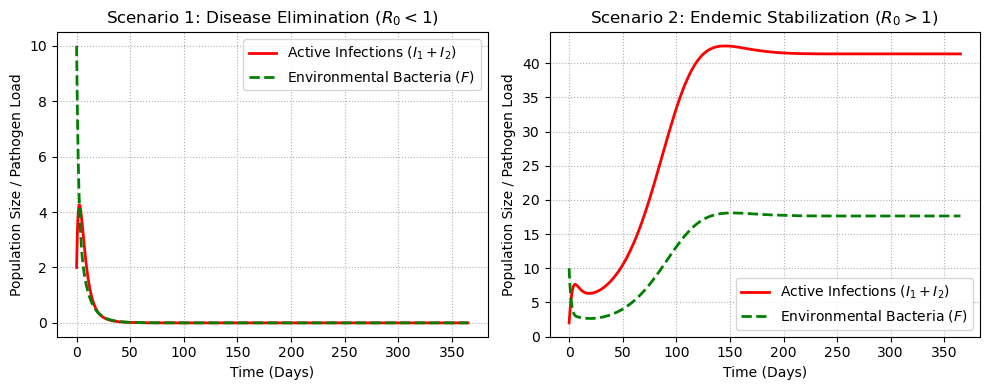

In [9]:

# Define the 10-compartment system of ODEs
def ints_model(t, x, params):
    S, E, I1, I2, C, T1, T2, V, F, R = x
    
    # Unpack parameters
    Lambda, mu, nu, epsilon, omega, kappa, z, tau_1, tau_2, \
    delta_1, delta_2, delta_3, sigma, gamma_1, gamma_2, \
    rho_1, rho_2, alpha_1, alpha_2, alpha_3, F_s, \
    beta_h1, beta_h2, beta_c, beta_f = params
    
    # Force of infection
    lambda_t = beta_h1 * I1 + beta_h2 * I2 + beta_c * C + beta_f * F
    
    # Differential Equations
    dS_dt = Lambda + epsilon * V + omega * R - lambda_t * S - (mu + nu) * S
    dE_dt = lambda_t * S - (kappa + mu) * E
    dI1_dt = kappa * E - (z + tau_1 + delta_1 + mu) * I1
    dI2_dt = z * I1 - (tau_2 + delta_2 + mu) * I2
    dC_dt = rho_1 * T1 + rho_2 * T2 - (sigma + mu) * C
    dT1_dt = tau_1 * I1 - (gamma_1 + rho_1 + mu) * T1
    dT2_dt = tau_2 * I2 - (gamma_2 + delta_3 + rho_2 + \
               mu) * T2
    dV_dt = nu * S - (epsilon + mu) * V
    dF_dt = alpha_1 * I1 + alpha_2 * I2 + alpha_3 * C - F_s * F
    dR_dt = gamma_1 * T1 + gamma_2 * T2 + sigma * C - (omega + \
               mu) * R
    
    return [dS_dt, dE_dt, dI1_dt, dI2_dt, dC_dt, dT1_dt, dT2_dt, dV_dt, dF_dt, dR_dt]

# Base Model Parameter Values 
Lambda = 10.0      
mu = 0.02         
nu = 0.05         
epsilon = 0.1     
omega = 0.05      
kappa = 0.5       
z = 0.2           
tau_1 = 0.1       
tau_2 = 0.2       
delta_1 = 0.01    
delta_2 = 0.05    
delta_3 = 0.02    
sigma = 0.1       
gamma_1 = 0.3     
gamma_2 = 0.2     
rho_1 = 0.05      
rho_2 = 0.05      
alpha_1 = 0.1     
alpha_2 = 0.2     
alpha_3 = 0.15    
F_s = 0.4         

# Human baseline transmission coefficients
beta_h1 = 0.0001
beta_h2 = 0.0002
beta_c = 0.0001

# Simulation Configuration
t_span = (0, 365)   # Time horizon of 365 days
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Set initial conditions 
S0 = 150.0; E0 = 5.0; I1_0 = 2.0; I2_0 = 0.0; C0 = 0.0
T1_0 = 0.0; T2_0 = 0.0; V0 = 50.0; F0 = 10.0; R0 = 0.0
x0 = [S0, E0, I1_0, I2_0, C0, T1_0, T2_0, V0, F0, R0]

# Sub-critical Parameter Selection (R0 < 1)
beta_f_low = 0.00005 
params_low = (Lambda, mu, nu, epsilon, omega, kappa, z, tau_1, tau_2,
              delta_1, delta_2, delta_3, sigma, gamma_1, gamma_2,
              rho_1, rho_2, alpha_1, alpha_2, alpha_3, F_s,
              beta_h1, beta_h2, beta_c, beta_f_low)
sol_low = solve_ivp(ints_model, t_span, x0, args=(params_low,), t_eval=t_eval)

#Super-critical Parameter Selection (R0 > 1)
beta_f_high = 0.002
params_high = (Lambda, mu, nu, epsilon, omega, kappa, z, tau_1, tau_2,
               delta_1, delta_2, delta_3, sigma, gamma_1, gamma_2,
               rho_1, rho_2, alpha_1, alpha_2, alpha_3, F_s,
               beta_h1, beta_h2, beta_c, beta_f_high)
sol_high = solve_ivp(ints_model, t_span, x0, args=(params_high,), t_eval=t_eval)

# Plotting the curves
plt.figure(figsize=(10, 4))

# Plot for R0 < 1
plt.subplot(1, 2, 1)
total_inf_low = sol_low.y[2] + sol_low.y[3] # I1 + I2
plt.plot(sol_low.t, total_inf_low, 'r-', linewidth=2, label='Active Infections ($I_1+I_2$)')
plt.plot(sol_low.t, sol_low.y[8], 'g--', linewidth=2, label='Environmental Bacteria ($F$)')
plt.title('Scenario 1: Disease Elimination ($R_0 < 1$)')
plt.xlabel('Time (Days)')
plt.ylabel('Population Size / Pathogen Load')
plt.grid(True, linestyle=':')
plt.legend()

# Plot for R0 > 1
plt.subplot(1, 2, 2)
total_inf_high = sol_high.y[2] + sol_high.y[3] # I1 + I2
plt.plot(sol_high.t, total_inf_high, 'r-', linewidth=2, label='Active Infections ($I_1+I_2$)')
plt.plot(sol_high.t, sol_high.y[8], 'g--', linewidth=2, label='Environmental Bacteria ($F$)')
plt.title('Scenario 2: Endemic Stabilization ($R_0 > 1$)')
plt.xlabel('Time (Days)')
plt.ylabel('Population Size / Pathogen Load')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.savefig("Bifurcation.png", dpi=100, bbox_inches='tight')

plt.show()